In [3]:
import sys
from pathlib import Path
import pandas as pd

sys.path.insert(0, str(Path(r"C:\Users\taylorhearn\git_repos\vascumap\bel_vascumap")))
from plotting import combine_outputs, pca_plots, plot_experiment_comparisons

# ── Experiment-specific config ────────────────────────────────────────────────
CONDITION_COLORS = {"vehicle": "red", "dexa": "dodgerblue"}

def find_condition(row):
    name = str(row["image_name"]).lower()
    if "270325.2" in name:
        return "vehicle"
    elif "270325" in name:
        return "dexa"

    return "NA"

In [4]:
root_dir = Path(r"Z:\Bel\Individual_Vascumap_Outputs\Defne_Vascumap")
output_dir = root_dir.parent / f"{root_dir.name}_output_data"
output_dir.mkdir(parents=True, exist_ok=True)

combined_analysis_metrics, combined_branch_metrics = combine_outputs(root_dir)
print(combined_analysis_metrics.shape)

Found extra uncategorised csv Z:\Bel\Individual_Vascumap_Outputs\Defne_Vascumap\270325.2_Device 2_Merged_img0\270325.2_Device 2_Merged_img0_all_morphological_params.csv
Found extra uncategorised csv Z:\Bel\Individual_Vascumap_Outputs\Defne_Vascumap\270325.2_Device 3_Merged_img1\270325.2_Device 3_Merged_img1_all_morphological_params.csv
Found extra uncategorised csv Z:\Bel\Individual_Vascumap_Outputs\Defne_Vascumap\270325.2_Device 3_Merged_img7\270325.2_Device 3_Merged_img7_all_morphological_params.csv
Found extra uncategorised csv Z:\Bel\Individual_Vascumap_Outputs\Defne_Vascumap\270325.2_Device 4_Merged_img2\270325.2_Device 4_Merged_img2_all_morphological_params.csv
Found extra uncategorised csv Z:\Bel\Individual_Vascumap_Outputs\Defne_Vascumap\270325.2_Device 4_Merged_img8\270325.2_Device 4_Merged_img8_all_morphological_params.csv
Found extra uncategorised csv Z:\Bel\Individual_Vascumap_Outputs\Defne_Vascumap\270325.2_Device 5_Merged_img3\270325.2_Device 5_Merged_img3_all_morphologic

In [5]:

combined_analysis_metrics["experiment"] = combined_analysis_metrics.apply(find_condition, axis=1)
print(f"{len(combined_analysis_metrics.image_name.unique())} unique images")

24 unique images


In [6]:
combined_analysis_metrics.experiment.unique()

array(['vehicle', 'dexa'], dtype=object)

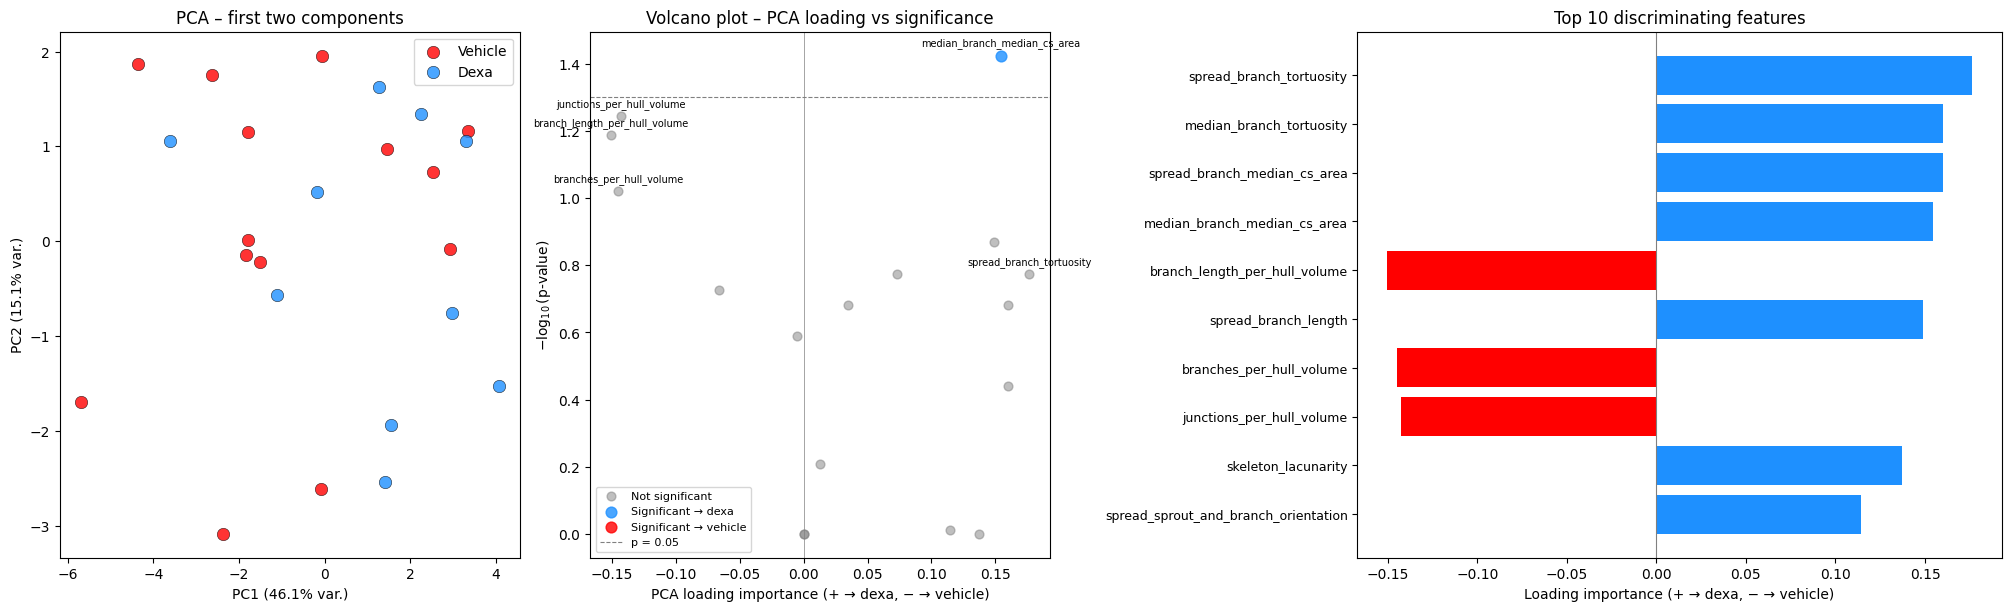

Significant features: 1 / 17


In [7]:
significant_params, top_params = pca_plots(combined_analysis_metrics, CONDITION_COLORS, save_dir=output_dir, save_type="pdf")

Saved: Z:\Bel\Individual_Vascumap_Outputs\Defne_Vascumap_output_data\significant_changes.png


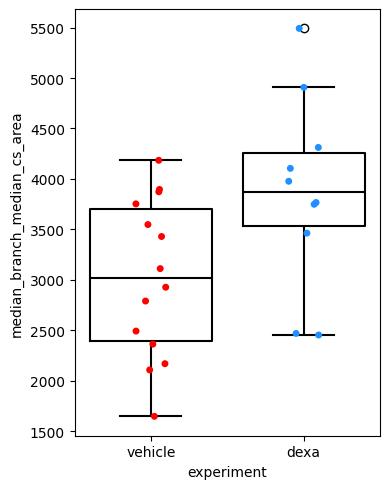

In [8]:
xorder = [c for c in CONDITION_COLORS if c in combined_analysis_metrics["experiment"].unique()]
plot_experiment_comparisons(
    combined_analysis_metrics,
    significant_params[:5], xorder, "significant_changes", output_dir, CONDITION_COLORS,
)

Saved: Z:\Bel\Individual_Vascumap_Outputs\Defne_Vascumap_output_data\top_params.pdf


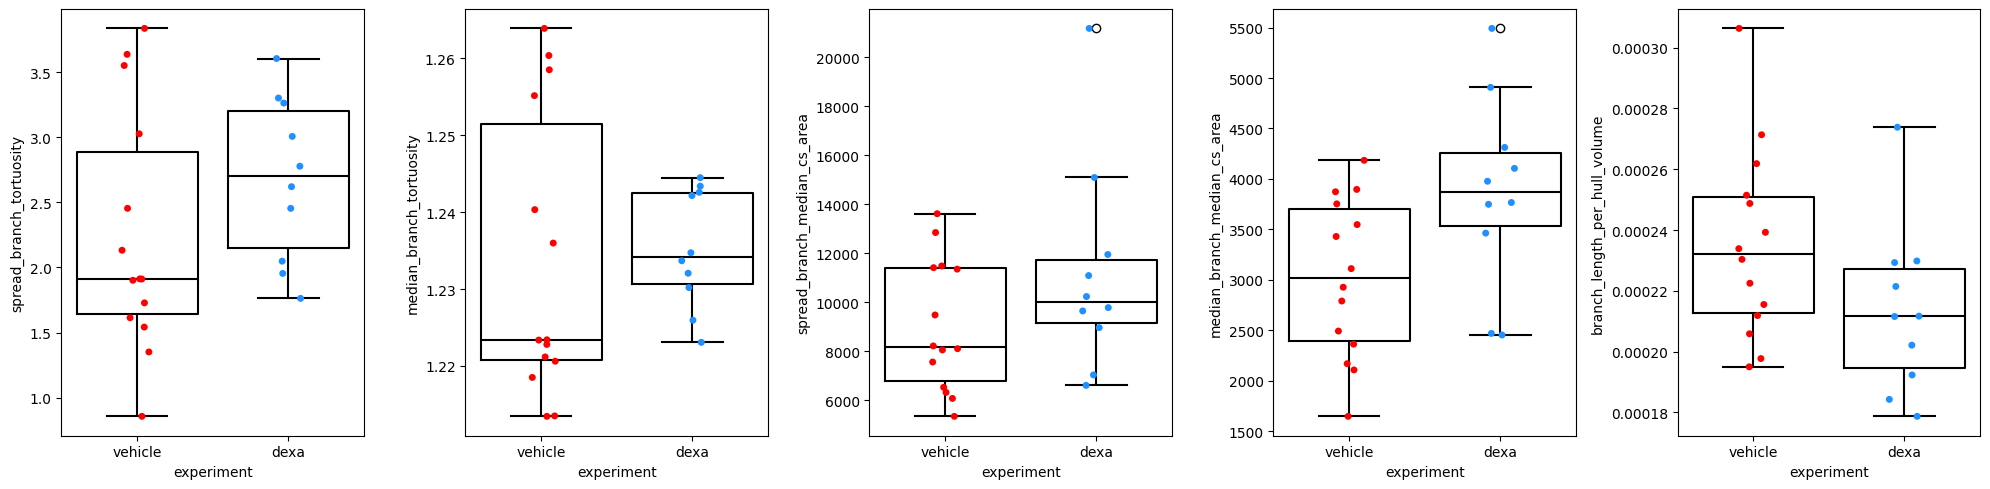

In [10]:
plot_experiment_comparisons(combined_analysis_metrics, top_params[:5], xorder, "top_params", output_dir, CONDITION_COLORS, save_type="pdf")